# Quadratic Trend Diagnostics for Sentiment and Breadth

This notebook follows up the residual-autocorrelation and curvature diagnostics from the scalar LSC trend tables. It does not replace the main annual trajectory figures or the main linear trend tables. The goal is narrower: visualise whether selected annual series are better described as curved trajectories than as simple monotonic linear trends.


The diagnostic scope is restricted to the rows that matter for reporting. Breadth is inspected for Autism because the existing diagnostics are strongest for Autism Overall and Clinical breadth. Sentiment is inspected for ADHD and Autism because the Clinical rows for both targets show residual-autocorrelation and large quadratic fit improvements. Lived-experience rows are omitted from the figures and diagnostic table because they were not flagged. Overall rows are retained in the figures as direct context for the flagged Clinical trajectories.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy import stats

pd.set_option("display.max_columns", 100)


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "reports").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


PROJECT_ROOT = find_project_root()
EXPECTED_YEARS = list(range(2014, 2027))
REPORT_FRAMES = ["substantive_core_overall", "clinical_only"]
FRAME_LABELS = {
    "substantive_core_overall": "Overall",
    "clinical_only": "Clinical",
}
FRAME_MARKERS = {
    "substantive_core_overall": "o",
    "clinical_only": "s",
}
FRAME_COLORS = {
    "ADHD": {
        "substantive_core_overall": "#2F6F9F",
        "clinical_only": "#6A96B8",
    },
    "Autism": {
        "substantive_core_overall": "#B66A4A",
        "clinical_only": "#C98662",
    },
}
FRAME_ORDER = {frame: index for index, frame in enumerate(REPORT_FRAMES)}
MEASURE_ORDER = {"Breadth": 0, "Sentiment": 1}
UNIT_ORDER = {"ADHD": 0, "Autism": 1}

PROCESSED_LSC_DIR = PROJECT_ROOT / "data" / "processed" / "lsc"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures" / "lsc" / "diagnostics"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "lsc" / "diagnostics"
for directory in [FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_SUMMARY_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_models.csv"
FLAGGED_MODEL_SUMMARY_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_flagged.csv"
FLAGGED_MODEL_TABLE_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_flagged.tex"
FIGURE_DATA_PATH = TABLE_DIR / "lsc_quadratic_trend_diagnostics_figure_data.csv"
BREADTH_FIGURE_PATH = FIGURE_DIR / "lsc_quadratic_diagnostics_breadth_autism.png"
SENTIMENT_FIGURE_PATH = FIGURE_DIR / "lsc_quadratic_diagnostics_sentiment_targets.png"
LSC_FIGURE_DPI = 300

plt.rcParams.update(
    {
        "axes.facecolor": "white",
        "figure.facecolor": "white",
        "axes.edgecolor": "#44515C",
        "axes.labelcolor": "#25313B",
        "xtick.color": "#25313B",
        "ytick.color": "#25313B",
        "font.size": 9.5,
    }
)


## Load Completed Annual Outputs

The notebook reads the existing annual estimates and trend summaries from the completed Sentiment and Breadth runs. It does not recompute collocates, embeddings, annual scores, bootstrap intervals, or the main linear trend models.


In [2]:
sentiment_annual = pd.read_csv(PROCESSED_LSC_DIR / "sentiment" / "lsc_sentiment_annual_valence.csv")
sentiment_trends = pd.read_csv(PROCESSED_LSC_DIR / "sentiment" / "lsc_sentiment_trend_models.csv")
breadth_annual = pd.read_csv(PROCESSED_LSC_DIR / "breadth" / "lsc_breadth_annual_scores.csv")
breadth_trends = pd.read_csv(PROCESSED_LSC_DIR / "breadth" / "lsc_breadth_trend_models.csv")

source_shapes = pd.DataFrame(
    [
        {"source": "Sentiment annual", "rows": len(sentiment_annual)},
        {"source": "Sentiment trend models", "rows": len(sentiment_trends)},
        {"source": "Breadth annual", "rows": len(breadth_annual)},
        {"source": "Breadth trend models", "rows": len(breadth_trends)},
    ]
)
source_shapes


,source,rows
0,Sentiment annual,143
1,Sentiment trend models,11
2,Breadth annual,143
3,Breadth trend models,11


## Fit Quadratic Diagnostics

Each selected annual series is fitted with a quadratic OLS model using the same centred-year convention as the main trend notebooks. The saved model summary keeps the plotted Overall and Clinical rows; the compact LaTeX table below reports only rows whose linear residual diagnostic was flagged.


In [3]:
DIAGNOSTIC_SERIES = [
    {
        "measure": "Breadth",
        "analysis_unit": "Autism",
        "annual": breadth_annual,
        "trends": breadth_trends,
        "value_column": "breadth_mean_pairwise_cosine_distance",
        "ci_low_column": "breadth_ci_low",
        "ci_high_column": "breadth_ci_high",
        "y_label": "Semantic breadth",
    },
    {
        "measure": "Sentiment",
        "analysis_unit": "ADHD",
        "annual": sentiment_annual,
        "trends": sentiment_trends,
        "value_column": "valence_mean",
        "ci_low_column": "valence_ci_low",
        "ci_high_column": "valence_ci_high",
        "y_label": "Valence",
    },
    {
        "measure": "Sentiment",
        "analysis_unit": "Autism",
        "annual": sentiment_annual,
        "trends": sentiment_trends,
        "value_column": "valence_mean",
        "ci_low_column": "valence_ci_low",
        "ci_high_column": "valence_ci_high",
        "y_label": "Valence",
    },
]


def linear_trend_row(trends: pd.DataFrame, unit: str, frame_stratum: str) -> pd.Series:
    row = trends.loc[trends["analysis_unit"].eq(unit) & trends["frame_stratum"].eq(frame_stratum)]
    if row.empty:
        raise ValueError(f"No linear trend row found for {unit}/{frame_stratum}.")
    if len(row) > 1:
        raise ValueError(f"Multiple linear trend rows found for {unit}/{frame_stratum}.")
    return row.iloc[0]


def fit_quadratic_diagnostic(series: pd.DataFrame, value_column: str) -> dict[str, float | bool | str]:
    data = series[["lsc_year", value_column]].dropna().sort_values("lsc_year")
    years = data["lsc_year"].to_numpy(dtype=float)
    values = data[value_column].to_numpy(dtype=float)
    n = len(values)
    if n < 6 or len(np.unique(values)) < 3:
        raise ValueError("Quadratic diagnostic requires at least six years and three unique values.")

    year_center = float(years.mean())
    x = years - year_center
    design = np.column_stack([np.ones(n), x, x**2])
    coefficients, *_ = np.linalg.lstsq(design, values, rcond=None)
    fitted = design @ coefficients
    residuals = values - fitted
    sse = float(np.sum(residuals**2))
    sst = float(np.sum((values - values.mean()) ** 2))
    r_squared = 1 - sse / sst if sst else np.nan
    df_resid = n - design.shape[1]
    adj_r_squared = 1 - (1 - r_squared) * (n - 1) / df_resid if df_resid > 0 and not np.isnan(r_squared) else np.nan

    sigma2 = sse / df_resid if df_resid > 0 else np.nan
    covariance = sigma2 * np.linalg.inv(design.T @ design) if df_resid > 0 else np.full((3, 3), np.nan)
    standard_errors = np.sqrt(np.diag(covariance))
    t_values = coefficients / standard_errors
    p_values = 2 * stats.t.sf(np.abs(t_values), df=df_resid)

    a = float(coefficients[2])
    b = float(coefficients[1])
    if a == 0:
        vertex_year = np.nan
        vertex_score = np.nan
        vertex_in_window = False
        curvature_direction = "linear"
    else:
        vertex_x = -b / (2 * a)
        vertex_year = float(year_center + vertex_x)
        vertex_score = float(coefficients[0] + b * vertex_x + a * vertex_x**2)
        vertex_in_window = bool(min(EXPECTED_YEARS) <= vertex_year <= max(EXPECTED_YEARS))
        curvature_direction = "inverted_u" if a < 0 else "u_shaped"

    return {
        "n_years": n,
        "year_center": year_center,
        "quadratic_intercept": float(coefficients[0]),
        "quadratic_year_coef": b,
        "quadratic_year_squared_coef": a,
        "quadratic_year_coef_se": float(standard_errors[1]),
        "quadratic_year_squared_coef_se": float(standard_errors[2]),
        "quadratic_year_coef_p_value": float(p_values[1]),
        "quadratic_year_squared_coef_p_value": float(p_values[2]),
        "quadratic_r_squared": float(r_squared),
        "quadratic_adj_r_squared": float(adj_r_squared),
        "vertex_year": vertex_year,
        "vertex_score": vertex_score,
        "vertex_in_observed_window": vertex_in_window,
        "curvature_direction": curvature_direction,
    }


model_rows = []
annual_rows = []
fit_rows = []
fit_years = np.linspace(min(EXPECTED_YEARS), max(EXPECTED_YEARS), 121)

for spec in DIAGNOSTIC_SERIES:
    for frame_stratum in REPORT_FRAMES:
        annual = spec["annual"]
        unit = spec["analysis_unit"]
        measure = spec["measure"]
        value_column = spec["value_column"]
        series = annual.loc[
            annual["analysis_unit"].eq(unit)
            & annual["frame_stratum"].eq(frame_stratum)
            & annual["lsc_year"].isin(EXPECTED_YEARS)
        ].sort_values("lsc_year").copy()
        if len(series) != len(EXPECTED_YEARS):
            raise ValueError(f"Expected {len(EXPECTED_YEARS)} rows for {measure}/{unit}/{frame_stratum}, found {len(series)}.")

        linear = linear_trend_row(spec["trends"], unit, frame_stratum)
        quadratic = fit_quadratic_diagnostic(series, value_column)
        diagnostic_role = "flagged" if bool(linear["autocorrelation_flag"]) else "context"
        linear_fitted = linear["linear_intercept"] + linear["linear_slope_per_year"] * (series["lsc_year"] - linear["year_center"])
        year_center = quadratic["year_center"]
        quadratic_fitted = (
            quadratic["quadratic_intercept"]
            + quadratic["quadratic_year_coef"] * (series["lsc_year"] - year_center)
            + quadratic["quadratic_year_squared_coef"] * (series["lsc_year"] - year_center) ** 2
        )
        quadratic_fit_grid = (
            quadratic["quadratic_intercept"]
            + quadratic["quadratic_year_coef"] * (fit_years - year_center)
            + quadratic["quadratic_year_squared_coef"] * (fit_years - year_center) ** 2
        )
        linear_fit_grid = linear["linear_intercept"] + linear["linear_slope_per_year"] * (fit_years - linear["year_center"])

        model_rows.append(
            {
                "measure": measure,
                "analysis_unit": unit,
                "frame_stratum": frame_stratum,
                "frame_label": FRAME_LABELS[frame_stratum],
                "diagnostic_role": diagnostic_role,
                "value_column": value_column,
                "linear_slope_per_year": linear["linear_slope_per_year"],
                "linear_slope_se": linear["linear_slope_se"],
                "linear_p_value": linear["linear_p_value"],
                "linear_adj_r_squared": linear["linear_adj_r_squared"],
                "autocorrelation_flag": bool(linear["autocorrelation_flag"]),
                "ar1_sensitivity_slope_per_year": linear.get("ar1_sensitivity_slope_per_year", np.nan),
                "ar1_sensitivity_p_value": linear.get("ar1_sensitivity_p_value", np.nan),
                **quadratic,
                "quadratic_delta_adj_r_squared": quadratic["quadratic_adj_r_squared"] - linear["linear_adj_r_squared"],
                "observed_2014": float(series.loc[series["lsc_year"].eq(2014), value_column].iloc[0]),
                "observed_2026": float(series.loc[series["lsc_year"].eq(2026), value_column].iloc[0]),
            }
        )

        annual_out = series[["lsc_year", value_column, spec["ci_low_column"], spec["ci_high_column"]]].copy()
        annual_out = annual_out.rename(
            columns={
                value_column: "score",
                spec["ci_low_column"]: "ci_low",
                spec["ci_high_column"]: "ci_high",
            }
        )
        annual_out["measure"] = measure
        annual_out["analysis_unit"] = unit
        annual_out["frame_stratum"] = frame_stratum
        annual_out["frame_label"] = FRAME_LABELS[frame_stratum]
        annual_out["diagnostic_role"] = diagnostic_role
        annual_out["row_type"] = "annual_estimate"
        annual_out["linear_fit"] = linear_fitted.to_numpy(dtype=float)
        annual_out["quadratic_fit_at_year"] = quadratic_fitted.to_numpy(dtype=float)
        annual_rows.append(annual_out)

        fit_rows.append(
            pd.DataFrame(
                {
                    "lsc_year": fit_years,
                    "measure": measure,
                    "analysis_unit": unit,
                    "frame_stratum": frame_stratum,
                    "frame_label": FRAME_LABELS[frame_stratum],
                    "diagnostic_role": diagnostic_role,
                    "row_type": "linear_fit",
                    "fit_score": linear_fit_grid,
                }
            )
        )
        fit_rows.append(
            pd.DataFrame(
                {
                    "lsc_year": fit_years,
                    "measure": measure,
                    "analysis_unit": unit,
                    "frame_stratum": frame_stratum,
                    "frame_label": FRAME_LABELS[frame_stratum],
                    "diagnostic_role": diagnostic_role,
                    "row_type": "quadratic_fit",
                    "fit_score": quadratic_fit_grid,
                }
            )
        )

model_summary = pd.DataFrame(model_rows)
model_summary["measure_order"] = model_summary["measure"].map(MEASURE_ORDER)
model_summary["unit_order"] = model_summary["analysis_unit"].map(UNIT_ORDER)
model_summary["frame_order"] = model_summary["frame_stratum"].map(FRAME_ORDER)
model_summary = (
    model_summary.sort_values(["measure_order", "unit_order", "frame_order"])
    .drop(columns=["measure_order", "unit_order", "frame_order"])
    .reset_index(drop=True)
)
annual_figure_data = pd.concat(annual_rows, ignore_index=True)
fit_figure_data = pd.concat(fit_rows, ignore_index=True)
figure_data = pd.concat([annual_figure_data, fit_figure_data], ignore_index=True, sort=False)
flagged_model_summary = model_summary.loc[model_summary["autocorrelation_flag"]].copy()

model_summary.to_csv(MODEL_SUMMARY_PATH, index=False)
flagged_model_summary.to_csv(FLAGGED_MODEL_SUMMARY_PATH, index=False)
figure_data.to_csv(FIGURE_DATA_PATH, index=False)

print(f"Wrote {MODEL_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {FLAGGED_MODEL_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {FIGURE_DATA_PATH.relative_to(PROJECT_ROOT)}")
display(model_summary[[
    "measure", "analysis_unit", "frame_label", "diagnostic_role", "linear_slope_per_year", "linear_p_value",
    "linear_adj_r_squared", "quadratic_adj_r_squared", "quadratic_delta_adj_r_squared",
    "vertex_year", "vertex_in_observed_window", "autocorrelation_flag",
]])


Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_models.csv
Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.csv
Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_figure_data.csv


,measure,analysis_unit,frame_label,diagnostic_role,linear_slope_per_year,linear_p_value,linear_adj_r_squared,quadratic_adj_r_squared,quadratic_delta_adj_r_squared,vertex_year,vertex_in_observed_window,autocorrelation_flag
0,Breadth,Autism,Overall,flagged,0.000119,0.637442,-0.068103,0.510775,0.578878,2020.317193,True,True
1,Breadth,Autism,Clinical,flagged,0.000749,0.036319,0.280485,0.789346,0.508861,2021.390791,True,True
2,Sentiment,ADHD,Overall,context,0.001216,0.098643,0.158172,0.431893,0.273722,2018.549061,True,False
3,Sentiment,ADHD,Clinical,flagged,0.000427,0.631173,-0.067253,0.536658,0.603911,2019.682672,True,True
4,Sentiment,Autism,Overall,context,0.000571,0.110393,0.143761,0.236973,0.093212,2018.007653,True,False
5,Sentiment,Autism,Clinical,flagged,0.001154,0.228067,0.049842,0.655692,0.605850,2019.220582,True,True


## Visualise Quadratic Fits

The figures show the observed annual estimates and their bootstrap intervals, then overlay the original linear fit and the diagnostic quadratic fit. Overall and Clinical are drawn with the same visual weight; the distinction is interpretive rather than hierarchical.


In [4]:
def style_axis(ax: plt.Axes) -> None:
    ax.grid(axis="y", color="#E7EBEE", linewidth=0.8)
    ax.grid(axis="x", color="#EEF1F3", linewidth=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#AAB4BC")
    ax.spines["bottom"].set_color("#AAB4BC")
    ax.set_xticks(EXPECTED_YEARS[::2])
    ax.tick_params(axis="x", labelsize=8.5)
    ax.tick_params(axis="y", labelsize=8.5)


def set_panel_ylim(ax: plt.Axes, measure: str, unit: str) -> None:
    annual = annual_figure_data.loc[annual_figure_data["measure"].eq(measure) & annual_figure_data["analysis_unit"].eq(unit)]
    fits = fit_figure_data.loc[fit_figure_data["measure"].eq(measure) & fit_figure_data["analysis_unit"].eq(unit)]
    y_values = pd.concat([annual["ci_low"], annual["ci_high"], annual["score"], fits["fit_score"]]).dropna()
    y_min = float(y_values.min())
    y_max = float(y_values.max())
    padding = (y_max - y_min) * 0.09 if y_max > y_min else 0.01
    ax.set_ylim(y_min - padding, y_max + padding)


def plot_diagnostic_panel(ax: plt.Axes, measure: str, unit: str, *, y_label: str | None = None) -> None:
    for frame_stratum in REPORT_FRAMES:
        annual = annual_figure_data.loc[
            annual_figure_data["measure"].eq(measure)
            & annual_figure_data["analysis_unit"].eq(unit)
            & annual_figure_data["frame_stratum"].eq(frame_stratum)
        ].sort_values("lsc_year")
        line_fit = fit_figure_data.loc[
            fit_figure_data["measure"].eq(measure)
            & fit_figure_data["analysis_unit"].eq(unit)
            & fit_figure_data["frame_stratum"].eq(frame_stratum)
            & fit_figure_data["row_type"].eq("linear_fit")
        ].sort_values("lsc_year")
        quadratic_fit = fit_figure_data.loc[
            fit_figure_data["measure"].eq(measure)
            & fit_figure_data["analysis_unit"].eq(unit)
            & fit_figure_data["frame_stratum"].eq(frame_stratum)
            & fit_figure_data["row_type"].eq("quadratic_fit")
        ].sort_values("lsc_year")
        color = FRAME_COLORS[unit][frame_stratum]

        ax.fill_between(
            annual["lsc_year"].to_numpy(dtype=float),
            annual["ci_low"].to_numpy(dtype=float),
            annual["ci_high"].to_numpy(dtype=float),
            color=color,
            alpha=0.12,
            linewidth=0,
        )
        ax.plot(
            annual["lsc_year"],
            annual["score"],
            marker=FRAME_MARKERS[frame_stratum],
            markersize=4.4,
            linewidth=1.65,
            color=color,
            alpha=0.92,
            label=FRAME_LABELS[frame_stratum],
        )
        ax.plot(
            line_fit["lsc_year"],
            line_fit["fit_score"],
            color=color,
            linewidth=1.15,
            linestyle="--",
            alpha=0.68,
        )
        ax.plot(
            quadratic_fit["lsc_year"],
            quadratic_fit["fit_score"],
            color=color,
            linewidth=2.0,
            linestyle="-",
            alpha=0.98,
        )
    style_axis(ax)
    set_panel_ylim(ax, measure, unit)
    if y_label:
        ax.set_ylabel(y_label, fontsize=9.5)


def save_lsc_figure(fig: plt.Figure, png_path: Path) -> Path:
    fig.savefig(png_path, dpi=LSC_FIGURE_DPI, bbox_inches="tight", facecolor="white")
    pdf_path = png_path.with_suffix(".pdf")
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    return pdf_path


frame_legend_handles = [
    Line2D([0], [0], color="#44515C", marker=FRAME_MARKERS["substantive_core_overall"], linewidth=1.65, label="Overall + interval"),
    Line2D([0], [0], color="#44515C", marker=FRAME_MARKERS["clinical_only"], linewidth=1.65, label="Clinical + interval"),
]
fit_legend_handles = [
    Line2D([0], [0], color="#44515C", linestyle="--", linewidth=1.15, label="Linear fit"),
    Line2D([0], [0], color="#44515C", linestyle="-", linewidth=2.0, label="Quadratic fit"),
]
legend_handles = [*frame_legend_handles, *fit_legend_handles]


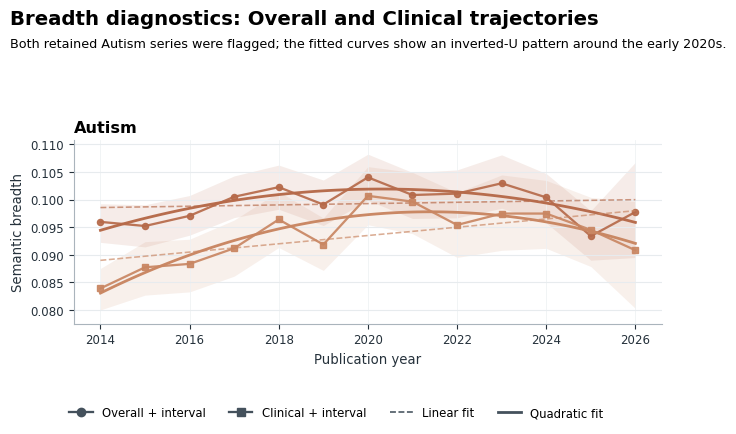

Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.png
Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.pdf


In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6.8, 3.95), sharex=True)
plot_diagnostic_panel(ax, "Breadth", "Autism", y_label="Semantic breadth")
ax.set_title("Autism", loc="left", fontsize=11.6, fontweight="bold", pad=6)
ax.set_xlabel("Publication year", fontsize=9.5)

fig.suptitle("Breadth diagnostics: Overall and Clinical trajectories", x=0.02, y=1.02, ha="left", fontsize=14.2, fontweight="bold")
fig.text(
    0.02,
    0.925,
    "Both retained Autism series were flagged; the fitted curves show an inverted-U pattern around the early 2020s.",
    fontsize=9.2,
)
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.045), frameon=False, fontsize=8.4, ncol=4)
fig.tight_layout(rect=[0, 0.08, 1, 0.86])
breadth_pdf = save_lsc_figure(fig, BREADTH_FIGURE_PATH)
plt.show()
print(f"Wrote {BREADTH_FIGURE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {breadth_pdf.relative_to(PROJECT_ROOT)}")


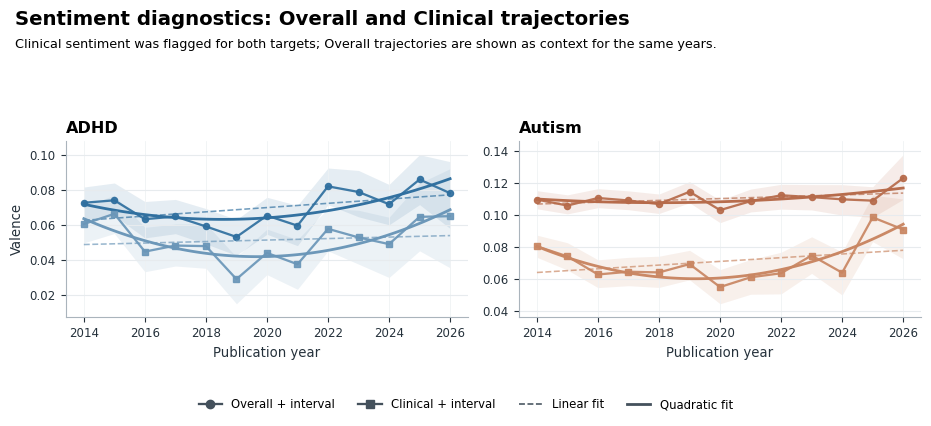

Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.png
Wrote reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.85), sharex=True, sharey=False)
for ax, unit in zip(axes, ["ADHD", "Autism"], strict=True):
    plot_diagnostic_panel(ax, "Sentiment", unit, y_label="Valence" if unit == "ADHD" else None)
    ax.set_title(unit, loc="left", fontsize=11.6, fontweight="bold", pad=6)
    ax.set_xlabel("Publication year", fontsize=9.5)

fig.suptitle("Sentiment diagnostics: Overall and Clinical trajectories", x=0.02, y=1.025, ha="left", fontsize=14.2, fontweight="bold")
fig.text(
    0.02,
    0.925,
    "Clinical sentiment was flagged for both targets; Overall trajectories are shown as context for the same years.",
    fontsize=9.2,
)
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.045), frameon=False, fontsize=8.4, ncol=4)
fig.tight_layout(rect=[0, 0.08, 1, 0.86])
sentiment_pdf = save_lsc_figure(fig, SENTIMENT_FIGURE_PATH)
plt.show()
print(f"Wrote {SENTIMENT_FIGURE_PATH.relative_to(PROJECT_ROOT)}")
print(f"Wrote {sentiment_pdf.relative_to(PROJECT_ROOT)}")


## Save Flagged Diagnostic Table

The appendix table reports only rows whose linear residual-autocorrelation diagnostic was flagged. Overall Sentiment remains in the figure for context but is not included in the table because it was not flagged.


In [7]:
def p_stars(p_value: float) -> str:
    if pd.isna(p_value):
        return ""
    if p_value < 0.001:
        return r"^{***}"
    if p_value < 0.01:
        return r"^{**}"
    if p_value < 0.05:
        return r"^{*}"
    return ""


def format_coef_se(coef: float, se: float, p_value: float) -> str:
    return rf"${coef:.4f}{p_stars(p_value)}$ ({se:.4f})"


def format_delta_adj_r2(value: float) -> str:
    return f"{value:.2f}"


def format_vertex(row: pd.Series) -> str:
    shape = "inverted U" if row["curvature_direction"] == "inverted_u" else "U"
    return f"{row['vertex_year']:.1f} ({shape})"


def make_flagged_quadratic_latex(table_data: pd.DataFrame) -> str:
    rows = []
    for _, row in table_data.iterrows():
        rows.append(
            " & ".join(
                [
                    row["measure"],
                    row["analysis_unit"],
                    row["frame_label"],
                    format_coef_se(row["linear_slope_per_year"], row["linear_slope_se"], row["linear_p_value"]),
                    format_coef_se(
                        row["quadratic_year_squared_coef"],
                        row["quadratic_year_squared_coef_se"],
                        row["quadratic_year_squared_coef_p_value"],
                    ),
                    format_delta_adj_r2(row["quadratic_delta_adj_r_squared"]),
                    format_vertex(row),
                ]
            )
            + r" \\" 
        )
    body = "\n".join(rows)
    lines = [
        r"\begin{table}[htbp]",
        r"\centering",
        r"\caption{Quadratic diagnostic trend models for flagged LSC trajectories.}",
        r"\label{tab:lsc-quadratic-diagnostics}",
        r"\scriptsize",
        r"\begin{tabular}{@{}lllcccc@{}}",
        r"\toprule",
        "Measure & Target & Frame & Linear $B(SE)$ & Quadratic $B_2(SE)$ & $\\Delta$ Adj. $R^2$ & Vertex \\\\",
        r"\midrule",
        body,
        r"\bottomrule",
        r"\end{tabular}",
        r"\parbox{\linewidth}{\footnotesize Note. Rows are restricted to annual series whose linear-model residual diagnostic was flagged for autocorrelation. Linear $B$ is the annual OLS slope from the main trend model. Quadratic $B_2$ is the centred-year-squared coefficient from the diagnostic model; $\Delta$ Adj. $R^2$ is the adjusted-$R^2$ gain over the linear model. Quadratic fits are diagnostic follow-ups, not replacements for the primary linear trend summaries. Significance markers are descriptive and uncorrected: $^{*}p<.05$, $^{**}p<.01$, $^{***}p<.001$.}",
        r"\end{table}",
        "",
    ]
    return "\n".join(lines)


FLAGGED_MODEL_TABLE_PATH.write_text(make_flagged_quadratic_latex(flagged_model_summary), encoding="utf-8")
print(f"Wrote {FLAGGED_MODEL_TABLE_PATH.relative_to(PROJECT_ROOT)}")
display(flagged_model_summary[[
    "measure", "analysis_unit", "frame_label", "linear_slope_per_year", "linear_slope_se",
    "quadratic_year_squared_coef", "quadratic_year_squared_coef_se", "quadratic_delta_adj_r_squared", "vertex_year",
]])


Wrote reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.tex


,measure,analysis_unit,frame_label,linear_slope_per_year,linear_slope_se,quadratic_year_squared_coef,quadratic_year_squared_coef_se,quadratic_delta_adj_r_squared,vertex_year
0,Breadth,Autism,Overall,0.000119,0.000245,-0.000187,0.000050,0.578878,2020.317193
1,Breadth,Autism,Clinical,0.000749,0.000315,-0.000269,0.000051,0.508861,2021.390791
3,Sentiment,ADHD,Clinical,0.000427,0.000865,0.000673,0.000172,0.603911,2019.682672
5,Sentiment,Autism,Clinical,0.001154,0.000904,0.000741,0.000164,0.605850,2019.220582


## Handoff

The model summary CSV keeps the plotted Overall and Clinical diagnostic rows. The flagged CSV and LaTeX table are narrower appendix outputs, restricted to the rows where the linear residual diagnostic was flagged. The figure-data CSV preserves the annual points and fitted values used in both figures.


In [8]:
print("Saved quadratic diagnostic outputs:")
for path in [
    MODEL_SUMMARY_PATH,
    FLAGGED_MODEL_SUMMARY_PATH,
    FLAGGED_MODEL_TABLE_PATH,
    FIGURE_DATA_PATH,
    BREADTH_FIGURE_PATH,
    BREADTH_FIGURE_PATH.with_suffix(".pdf"),
    SENTIMENT_FIGURE_PATH,
    SENTIMENT_FIGURE_PATH.with_suffix(".pdf"),
]:
    print(f"- {path.relative_to(PROJECT_ROOT)}")

print("\nDiagnostic model rows:", len(model_summary))
print("Flagged diagnostic rows:", len(flagged_model_summary))
print("Breadth rows:", int(model_summary["measure"].eq("Breadth").sum()))
print("Sentiment rows:", int(model_summary["measure"].eq("Sentiment").sum()))
print("Rows with in-window quadratic vertex:", int(model_summary["vertex_in_observed_window"].sum()))


Saved quadratic diagnostic outputs:
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_models.csv
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.csv
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_flagged.tex
- reports/tables/lsc/diagnostics/lsc_quadratic_trend_diagnostics_figure_data.csv
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.png
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_breadth_autism.pdf
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.png
- reports/figures/lsc/diagnostics/lsc_quadratic_diagnostics_sentiment_targets.pdf

Diagnostic model rows: 6
Flagged diagnostic rows: 4
Breadth rows: 2
Sentiment rows: 4
Rows with in-window quadratic vertex: 6
